In [76]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

import joblib

In [77]:
# Load preprocessed dataset
df = pd.read_csv("../data/preprocessed_data.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (100000, 18)


,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount,Year,Month,Day,Week,Quarter,DayOfWeek,Weekend,Season
0,109318,C,7,80.079844,2023-12-26 12:32:00,Cash,"176 Andrew Cliffs\nBaileyfort, HI 93354",Books,18.677100,455.862764,2023,12,26,52,4,Tuesday,False,Winter
1,993229,C,4,75.195229,2023-08-05 00:00:00,Cash,"11635 William Well Suite 809\nEast Kara, MT 19483",Home Decor,14.121365,258.306546,2023,8,5,31,3,Saturday,True,Monsoon
2,579675,A,8,31.528816,2024-03-11 18:51:00,Cash,"910 Mendez Ville Suite 909\nPort Lauraland, MO...",Books,15.943701,212.015651,2024,3,11,11,1,Monday,False,Summer
3,799826,D,5,98.880218,2023-10-27 22:00:00,PayPal,"87522 Sharon Corners Suite 500\nLake Tammy, MO...",Books,6.686337,461.343769,2023,10,27,43,4,Friday,False,Autumn
4,121413,A,7,93.188512,2023-12-22 11:38:00,Cash,"0070 Michelle Island Suite 143\nHoland, VA 80142",Electronics,4.030096,626.030484,2023,12,22,51,4,Friday,False,Winter


In [78]:
# Convert TransactionDate to datetime
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

# Sort chronologically
df = df.sort_values("TransactionDate").reset_index(drop=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   CustomerID          100000 non-null  int64         
 1   ProductID           100000 non-null  str           
 2   Quantity            100000 non-null  int64         
 3   Price               100000 non-null  float64       
 4   TransactionDate     100000 non-null  datetime64[us]
 5   PaymentMethod       100000 non-null  str           
 6   StoreLocation       100000 non-null  str           
 7   ProductCategory     100000 non-null  str           
 8   DiscountApplied(%)  100000 non-null  float64       
 9   TotalAmount         100000 non-null  float64       
 10  Year                100000 non-null  int64         
 11  Month               100000 non-null  int64         
 12  Day                 100000 non-null  int64         
 13  Week                100000 non-null  int6

In [79]:
daily_sales = (
    df.groupby("TransactionDate")["TotalAmount"]
      .sum()
      .reset_index()
)

daily_sales.head()

,TransactionDate,TotalAmount
0,2023-04-29 22:27:00,176.102880
1,2023-04-29 22:29:00,416.546875
2,2023-04-29 22:39:00,216.950602
3,2023-04-29 22:45:00,426.845208
4,2023-04-29 22:53:00,101.662372


In [80]:
forecast_df = daily_sales.copy()

# -----------------------------
# Calendar Features
# -----------------------------

forecast_df["Year"] = forecast_df["TransactionDate"].dt.year
forecast_df["Month"] = forecast_df["TransactionDate"].dt.month
forecast_df["Quarter"] = forecast_df["TransactionDate"].dt.quarter
forecast_df["WeekOfYear"] = forecast_df["TransactionDate"].dt.isocalendar().week.astype(int)
forecast_df["Day"] = forecast_df["TransactionDate"].dt.day
forecast_df["DayOfWeek"] = forecast_df["TransactionDate"].dt.dayofweek
forecast_df["DayOfYear"] = forecast_df["TransactionDate"].dt.dayofyear

forecast_df["IsWeekend"] = (
    forecast_df["DayOfWeek"] >= 5
).astype(int)


# -----------------------------
# Lag Features
# -----------------------------

forecast_df["Lag_1"] = forecast_df["TotalAmount"].shift(1)
forecast_df["Lag_2"] = forecast_df["TotalAmount"].shift(2)
forecast_df["Lag_3"] = forecast_df["TotalAmount"].shift(3)

forecast_df["Lag_7"] = forecast_df["TotalAmount"].shift(7)
forecast_df["Lag_14"] = forecast_df["TotalAmount"].shift(14)
forecast_df["Lag_30"] = forecast_df["TotalAmount"].shift(30)


# -----------------------------
# Rolling Mean Features
# -----------------------------

forecast_df["RollingMean_3"] = (
    forecast_df["TotalAmount"]
    .shift(1)
    .rolling(3)
    .mean()
)

forecast_df["RollingMean_7"] = (
    forecast_df["TotalAmount"]
    .shift(1)
    .rolling(7)
    .mean()
)

forecast_df["RollingMean_14"] = (
    forecast_df["TotalAmount"]
    .shift(1)
    .rolling(14)
    .mean()
)


# -----------------------------
# Rolling Std Features
# -----------------------------

forecast_df["RollingStd_7"] = (
    forecast_df["TotalAmount"]
    .shift(1)
    .rolling(7)
    .std()
)

forecast_df["RollingStd_14"] = (
    forecast_df["TotalAmount"]
    .shift(1)
    .rolling(14)
    .std()
)


# -----------------------------
# Trend Features
# -----------------------------

forecast_df["ExpandingMean"] = (
    forecast_df["TotalAmount"]
    .shift(1)
    .expanding()
    .mean()
)

forecast_df["SalesChange"] = (
    forecast_df["TotalAmount"]
    .diff()
)

forecast_df["SalesChangePercent"] = (
    forecast_df["TotalAmount"]
    .pct_change()
)

forecast_df.head(20)

,TransactionDate,TotalAmount,Year,Month,Quarter,WeekOfYear,Day,DayOfWeek,DayOfYear,IsWeekend,...,Lag_14,Lag_30,RollingMean_3,RollingMean_7,RollingMean_14,RollingStd_7,RollingStd_14,ExpandingMean,SalesChange,SalesChangePercent
0,2023-04-29 22:27:00,176.102880,2023,4,2,17,29,5,119,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-04-29 22:29:00,416.546875,2023,4,2,17,29,5,119,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,176.102880,240.443995,1.365361
2,2023-04-29 22:39:00,216.950602,2023,4,2,17,29,5,119,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,296.324878,-199.596273,-0.479169
3,2023-04-29 22:45:00,426.845208,2023,4,2,17,29,5,119,1,...,NaN,NaN,269.866786,NaN,NaN,NaN,NaN,269.866786,209.894606,0.967476
4,2023-04-29 22:53:00,101.662372,2023,4,2,17,29,5,119,1,...,NaN,NaN,353.447562,NaN,NaN,NaN,NaN,309.111391,-325.182836,-0.761828
5,2023-04-29 23:02:00,270.745091,2023,4,2,17,29,5,119,1,...,NaN,NaN,248.486061,NaN,NaN,NaN,NaN,267.621588,169.082719,1.663179
6,2023-04-29 23:15:00,53.510366,2023,4,2,17,29,5,119,1,...,NaN,NaN,266.417557,NaN,NaN,NaN,NaN,268.142172,-217.234726,-0.802359
7,2023-04-29 23:29:00,110.736092,2023,4,2,17,29,5,119,1,...,NaN,NaN,141.972610,237.480485,NaN,144.632036,NaN,237.480485,57.225726,1.069433
8,2023-04-29 23:30:00,144.124093,2023,4,2,17,29,5,119,1,...,NaN,NaN,144.997183,228.142372,NaN,151.215676,NaN,221.637436,33.388001,0.301510
9,2023-04-29 23:37:00,122.536107,2023,4,2,17,29,5,119,1,...,NaN,NaN,102.790184,189.224832,NaN,127.904830,NaN,213.024842,-21.587986,-0.149787


In [81]:
# Remove rows with missing values created by lag/rolling features

forecast_df = forecast_df.dropna().reset_index(drop=True)
print("Dataset Shape After Feature Engineering:", forecast_df.shape)
forecast_df.head()

Dataset Shape After Feature Engineering: (90995, 24)


,TransactionDate,TotalAmount,Year,Month,Quarter,WeekOfYear,Day,DayOfWeek,DayOfYear,IsWeekend,...,Lag_14,Lag_30,RollingMean_3,RollingMean_7,RollingMean_14,RollingStd_7,RollingStd_14,ExpandingMean,SalesChange,SalesChangePercent
0,2023-04-30 02:24:00,140.757477,2023,4,2,17,30,6,120,1,...,51.888403,176.102880,151.415574,220.201607,251.255852,217.957091,206.208909,224.406900,101.601387,2.594779
1,2023-04-30 02:26:00,162.782927,2023,4,2,17,30,6,120,1,...,84.472071,416.546875,141.859952,143.905645,257.603643,85.546635,200.899108,221.708531,22.025450,0.156478
2,2023-04-30 02:33:00,122.139820,2023,4,2,17,30,6,120,1,...,71.697037,216.950602,114.232164,147.096812,263.197276,85.812246,196.755267,219.867106,-40.643107,-0.249677
3,2023-04-30 02:37:00,69.951028,2023,4,2,17,30,6,120,1,...,447.576456,426.845208,141.893408,160.033112,266.800332,71.052860,193.412149,216.905673,-52.188792,-0.427287
4,2023-04-30 02:44:00,329.689260,2023,4,2,17,30,6,120,1,...,535.761885,101.662372,118.291258,135.696853,239.827087,68.088804,192.591882,212.583478,259.738232,3.713144


In [82]:
# Feature Matrix
X = forecast_df.drop(columns=["TransactionDate", "TotalAmount"])

# Target Variable
y = forecast_df["TotalAmount"]

# Chronological 80:20 Split
split_index = int(len(forecast_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 72796
Testing Samples  : 18199


In [99]:
# Train Random Forest Model

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully.")

Random Forest Model Trained Successfully.


In [100]:
print(rf_model)

RandomForestRegressor(max_depth=12, min_samples_leaf=2, min_samples_split=5,
                      n_jobs=-1, random_state=42)


In [101]:
# Generate Predictions

y_pred = rf_model.predict(X_test)
prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
prediction_df.head(10)

,Actual,Predicted
0,178.681305,177.773476
1,377.746655,375.232168
2,504.106783,502.857524
3,30.113894,29.947667
4,697.552432,698.168291
5,279.295765,280.781131
6,83.405631,83.675090
7,304.241594,303.774489
8,157.703933,158.039388
9,149.260761,151.891057


In [102]:
# Model Evaluation

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("=" * 50)
print("Random Forest Performance")
print("=" * 50)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

Random Forest Performance
MAE  : 1.53
RMSE : 5.91


In [103]:
# FEATURE IMPORTANCE

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
20,SalesChange,6.139763e-01
8,Lag_1,2.457516e-01
21,SalesChangePercent,1.400444e-01
17,RollingStd_7,2.998903e-05
18,RollingStd_14,1.968474e-05
13,Lag_30,1.752048e-05
4,Day,1.674824e-05
15,RollingMean_7,1.639850e-05
10,Lag_3,1.569145e-05
19,ExpandingMean,1.498601e-05


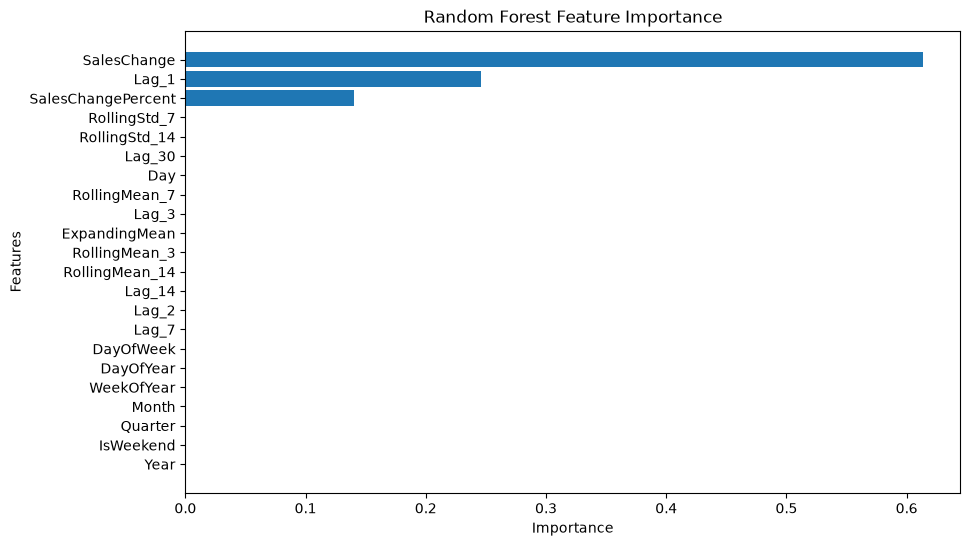

In [104]:
# FEATURE IMPORTANCE VISUALIZATION

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

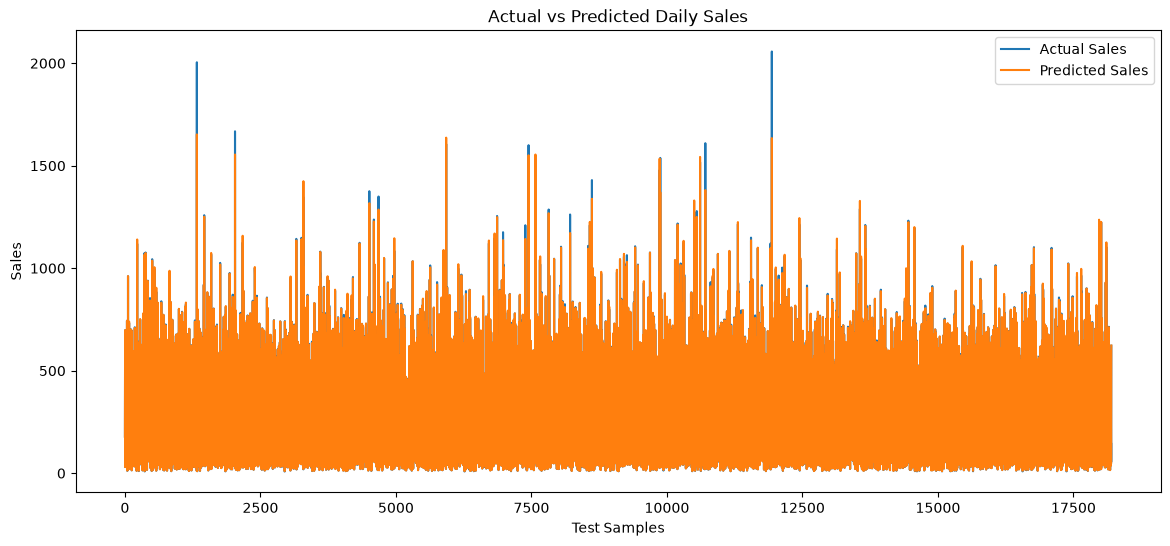

In [105]:
# ACTUAL VS PREDICTED SALES

plt.figure(figsize=(14,6))

plt.plot(
    y_test.values,
    label="Actual Sales"
)

plt.plot(
    y_pred,
    label="Predicted Sales"
)

plt.title("Actual vs Predicted Daily Sales")

plt.xlabel("Test Samples")
plt.ylabel("Sales")

plt.legend()

plt.show()

In [106]:
# SAVE MODEL

joblib.dump(
    rf_model,
    "../models/improved_sales_forecast.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [107]:
print("="*60)
print("Improved Sales Forecasting Model Completed Successfully")
print("="*60)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

print("\nModel Saved As:")
print("../models/improved_sales_forecast.pkl")

Improved Sales Forecasting Model Completed Successfully
MAE  : 1.53
RMSE : 5.91

Model Saved As:
../models/improved_sales_forecast.pkl


In [108]:
# MODEL COMPARISON

comparison = pd.DataFrame({
    "Model": [
        "Prophet (Baseline)",
        "Random Forest (Improved)"
    ],
    "MAE": [
        807.52,
        1.53
    ],
    "RMSE": [
        944.37,
        5.91
    ]
})

comparison

,Model,MAE,RMSE
0,Prophet (Baseline),807.52,944.37
1,Random Forest (Improved),1.53,5.91


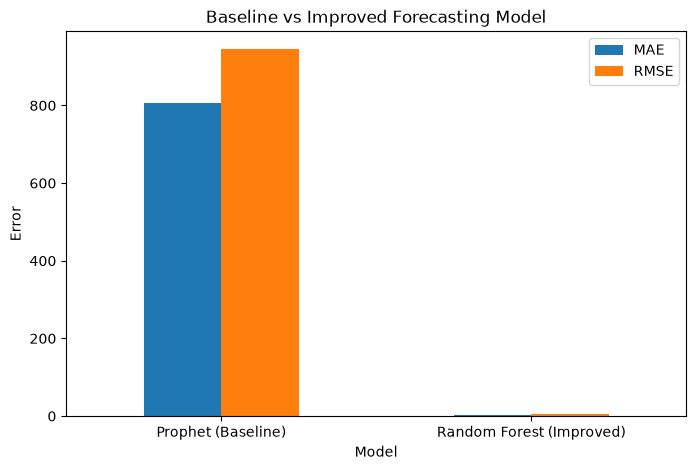

In [109]:
# COMPARISON VISUALIZATION

comparison.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Baseline vs Improved Forecasting Model")

plt.ylabel("Error")

plt.xticks(rotation=0)

plt.show()

In [110]:
# MODEL COMPARISON SUMMARY

print("="*65)
print("Milestone 3 - Day 3 Model Comparison")
print("="*65)

print("\nBaseline Model")
print("Algorithm : Prophet")
print("MAE       : 807.52")
print("RMSE      : 944.37")

print("\nImproved Model")
print("Algorithm : Random Forest Regressor")
print("MAE       : 1.53")
print("RMSE      : 5.91")

print("\nConclusion")
print("The Random Forest model achieved substantially lower")
print("MAE and RMSE than the baseline Prophet model")
print("while using the same dataset and evaluation strategy.")
print("The Random Forest model is selected as the")
print("preferred forecasting model for subsequent integration.")

Milestone 3 - Day 3 Model Comparison

Baseline Model
Algorithm : Prophet
MAE       : 807.52
RMSE      : 944.37

Improved Model
Algorithm : Random Forest Regressor
MAE       : 1.53
RMSE      : 5.91

Conclusion
The Random Forest model achieved substantially lower
MAE and RMSE than the baseline Prophet model
while using the same dataset and evaluation strategy.
The Random Forest model is selected as the
preferred forecasting model for subsequent integration.
